In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

    rows.append(row)


df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          46      2      7     1    2      7-1       True  2.237906e+06   
1          37      2      7     9    1      7-9       True  4.941267e+06   
2          13      1      3     6    2      3-6       True  1.698831e+07   
3          39      2      7     1    2      7-1       True  1.858398e+06   
4          38      2      5     8    2      5-8       True  6.086095e+07   

       EE_NJS  columna_rot_joint_disp  columna_flex_joint_disp  \
0  106.194105                0.167149                 0.383266   
1   86.883654                0.026298                 0.135622   
2  161.275011                0.233594                 0.219184   
3  119.390008                0.163400                 0.402870   
4  421.636214                0.123323                 0.474732   

   sternoclavicular_yaw_joint_disp  sternoclavicular_pitch_joint_disp  \
0                        -0.107506                           0.473812   


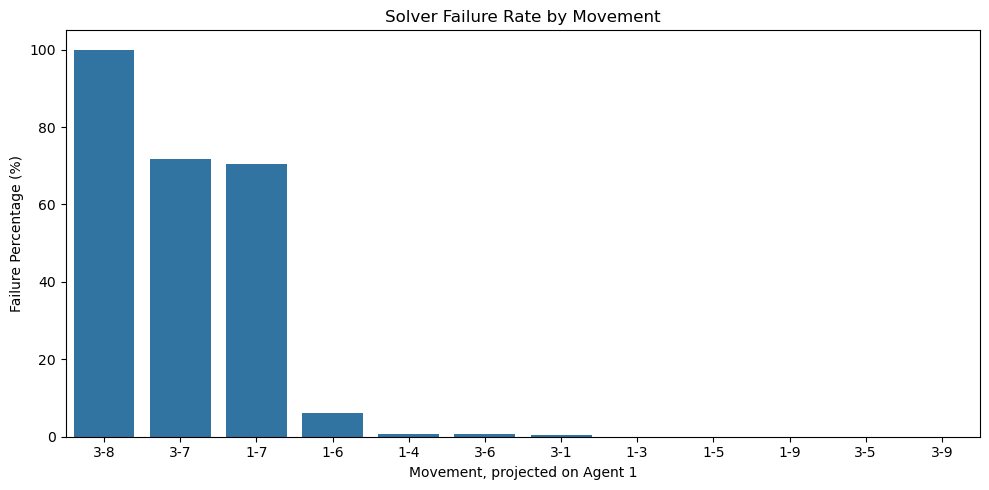

In [ ]:
df["failure"] = ~df["converged"]

mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df["projected_movement"] = np.where(
    df["agent"] == 1,
    df["movement"],
    df.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)

failure_rates = (
    df.groupby("projected_movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="projected_movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage (%)")
plt.xlabel("Movement, projected on Agent 1")
plt.title("Solver Failure Rate by Movement, projected on Agent 1")

plt.tight_layout()
plt.show()

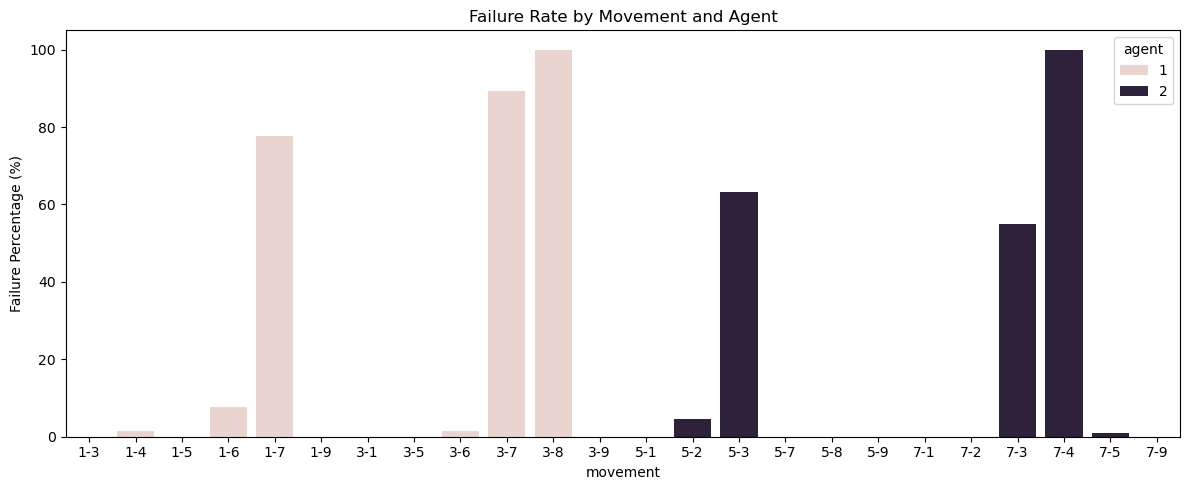

In [18]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage (%)")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [19]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    860
Name: count, dtype: int64
agent
1    861
2    860
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2    [7-1, 7-9, 5-8, 5-7, 7-5, 7-3, 7-2, 5-3, 5-2, ...
Name: movement, dtype: object


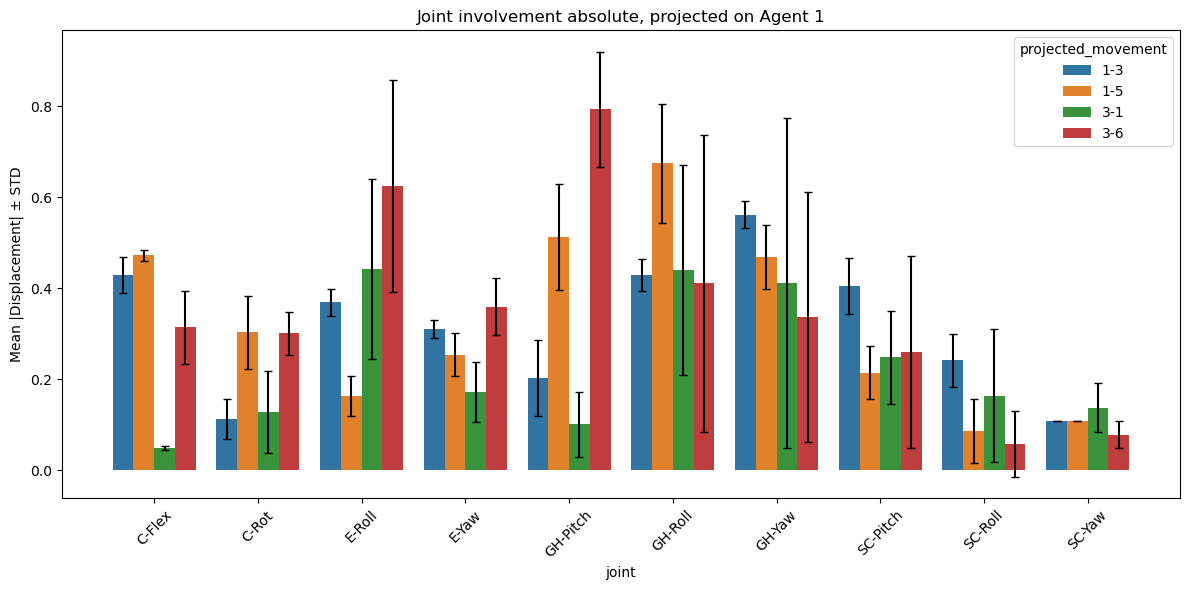

In [ ]:
joint_order = [
    "columna_rot_joint",
    "columna_flex_joint",
    "sternoclavicular_yaw_joint",
    "sternoclavicular_pitch_joint",
    "sternoclavicular_roll_joint",
    "glenohumeral_yaw_joint",
    "glenohumeral_pitch_joint",
    "glenohumeral_roll_joint",
    "elbow_yaw_joint",
    "elbow_roll_joint",
]

movements = ["1-3", "1-5", "3-6" ] #, "3-1"]

rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    for j in joint_order:
        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "disp": abs(row[f"{j}_disp"])
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("disp", "mean"),
    std=("disp", "std")
).reset_index()

joint_labels = {
    "columna_rot_joint": "C-Rot",
    "columna_flex_joint": "C-Flex",
    "sternoclavicular_yaw_joint": "SC-Yaw",
    "sternoclavicular_pitch_joint": "SC-Pitch",
    "sternoclavicular_roll_joint": "SC-Roll",
    "glenohumeral_yaw_joint": "GH-Yaw",
    "glenohumeral_pitch_joint": "GH-Pitch",
    "glenohumeral_roll_joint": "GH-Roll",
    "elbow_yaw_joint": "E-Yaw",
    "elbow_roll_joint": "E-Roll",
}

stats["joint"] = stats["joint"].map(joint_labels)

plt.figure(figsize=(12,6))
ax = plt.gca()

stats["joint"] = pd.Categorical(
    stats["joint"],
    categories=stats["joint"].unique(),
    ordered=True
)

sns.barplot(
    data=stats,
    x="joint",
    y="mean",
    hue="projected_movement",
    errorbar=None,
    ax=ax
)

for patch, (_, row) in zip(ax.patches, stats.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.errorbar(
        x=x,
        y=y,
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        capsize=3
    )

plt.xticks(rotation=45)
plt.ylabel("Mean |Displacement| ± STD")
plt.title("Joint involvement absolute, projected on Agent 1")
plt.tight_layout()
plt.show()

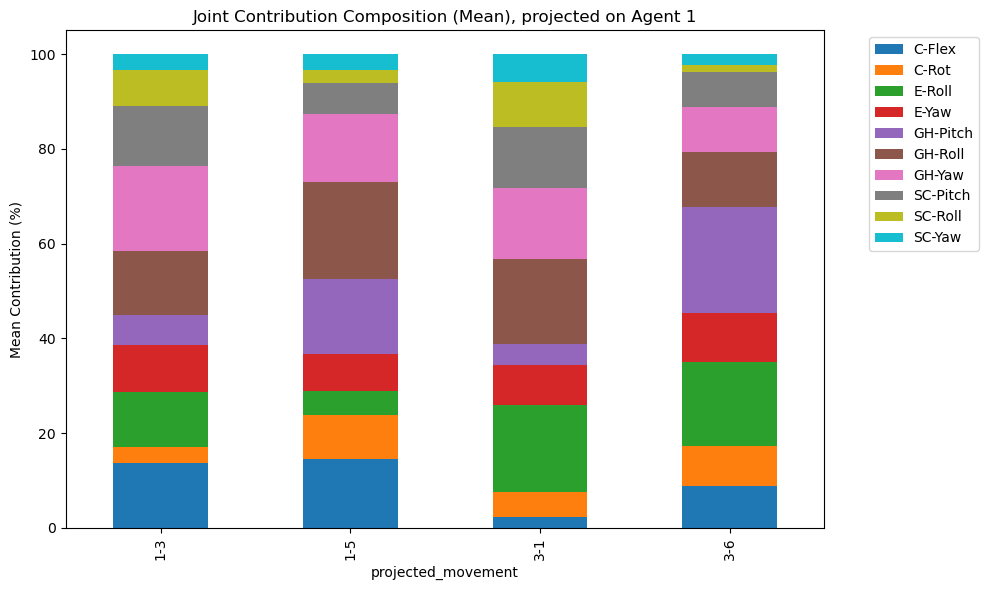

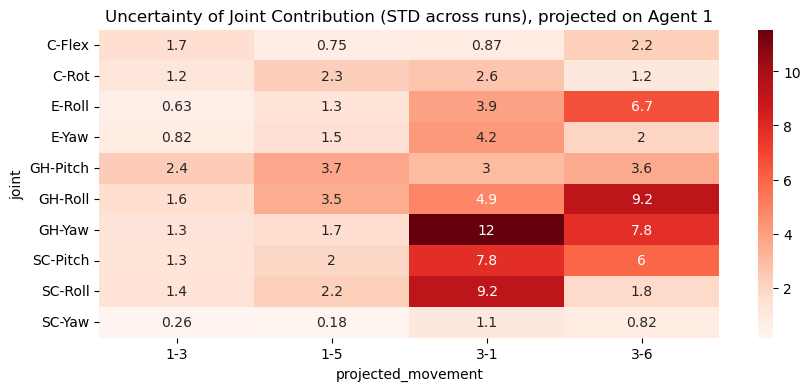

In [24]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

stats["joint"] = stats["joint"].map(joint_labels)

pivot = stats.pivot(
    index="projected_movement",
    columns="joint",
    values="mean"
)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Mean Contribution (%)")
plt.title("Joint Contribution Composition (Mean), projected on Agent 1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

err = stats.pivot(
    columns="projected_movement",
    index="joint",
    values="std"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    err,
    annot=True,
    cmap="Reds"
)

plt.title("Uncertainty of Joint Contribution (STD across runs), projected on Agent 1")
plt.show()

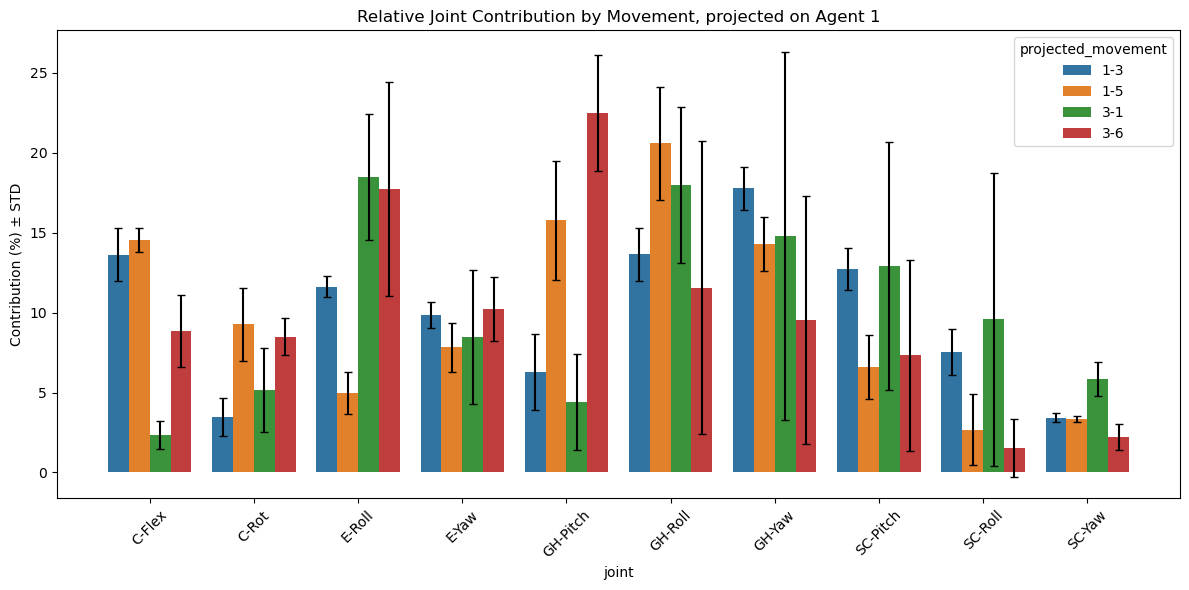

In [25]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):

        rows.append({
            "projected_movement": row["projected_movement"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

stats = long_df.groupby(["projected_movement", "joint"]).agg(
    mean=("contribution", "mean"),
    std=("contribution", "std")
).reset_index()

stats["joint"] = stats["joint"].map(joint_labels)


plt.figure(figsize=(12,6))
ax = plt.gca()

sns.barplot(
    data=stats,
    x="joint",
    y="mean",
    hue="projected_movement",
    errorbar=None,
    ax=ax
)

for patch, (_, row) in zip(ax.patches, stats.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.errorbar(
        x=x,
        y=y,
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        capsize=3
    )

plt.xticks(rotation=45)
plt.ylabel("Contribution (%) ± STD")
plt.title("Relative Joint Contribution by Movement, projected on Agent 1")
plt.tight_layout()
plt.show()

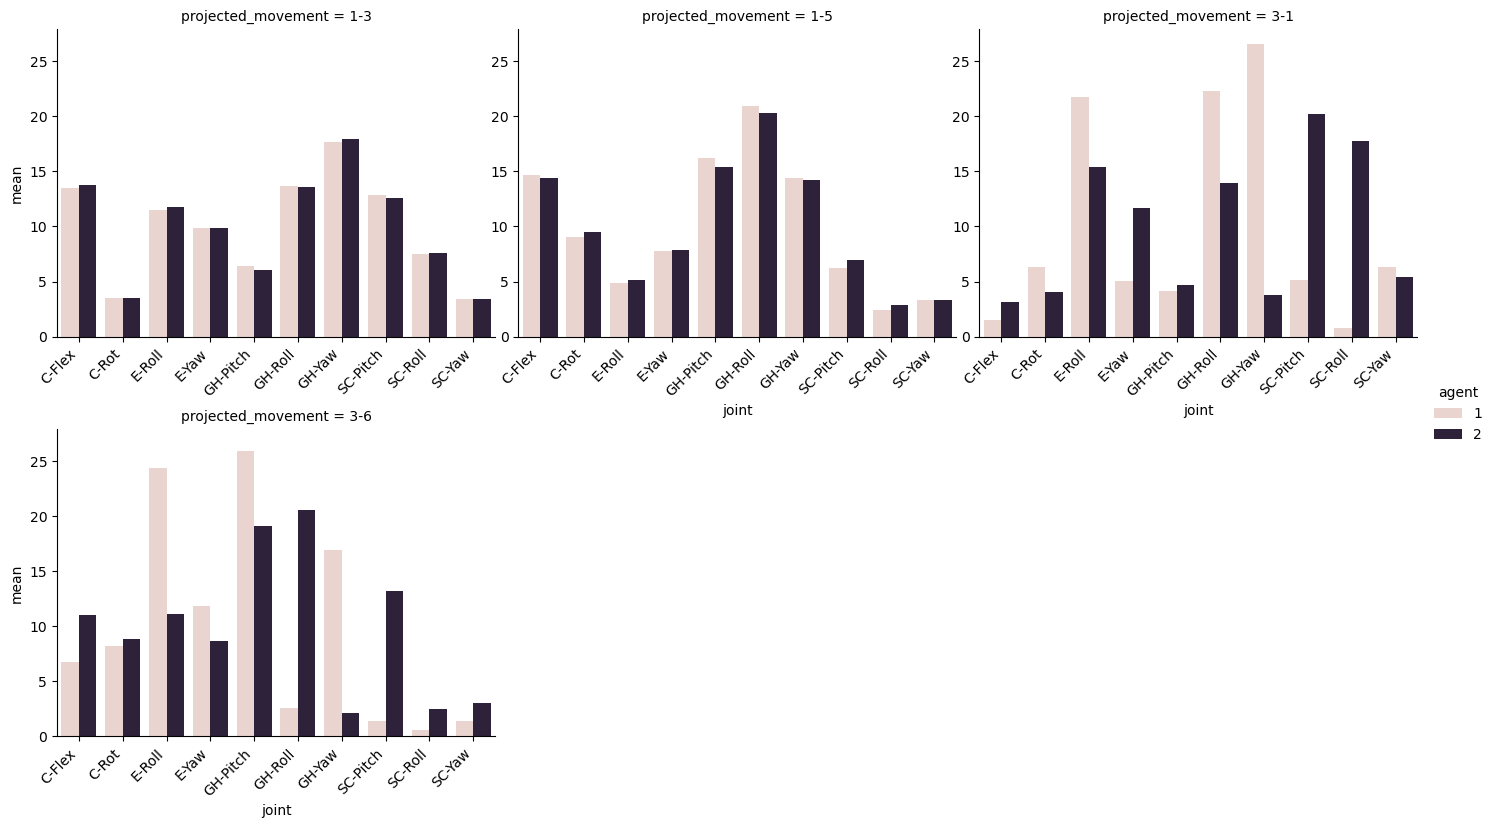

In [43]:
rows = []

for _, row in df[df["converged"]].iterrows():

    if row["projected_movement"] not in movements:
        continue

    disp = np.array([abs(row[f"{j}_disp"]) for j in joint_order])
    total = disp.sum()

    if total == 0:
        continue

    contrib = disp / total

    for j, c in zip(joint_order, contrib):
        rows.append({
            "projected_movement": row["projected_movement"],
            "agent": row["agent"],
            "joint": j,
            "contribution": c * 100
        })

long_df = pd.DataFrame(rows)

stats = (
    long_df
    .groupby(["projected_movement", "agent", "joint"])
    .agg(
        mean=("contribution", "mean"),
        std=("contribution", "std")
    )
    .reset_index()
)

stats["joint"] = stats["joint"].map(joint_labels)


g = sns.catplot(
    data=stats,
    kind="bar",
    x="joint",
    y="mean",
    hue="agent",
    col="projected_movement",
    col_wrap=3,
    height=4,
    aspect=1.2,
    errorbar=None,
    sharey=True
)

g.fig.subplots_adjust(hspace=0.3)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    
for ax in g.axes.flat:
    ax.tick_params(axis="y", labelleft=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(),
             rotation=45,
             ha="right")
    


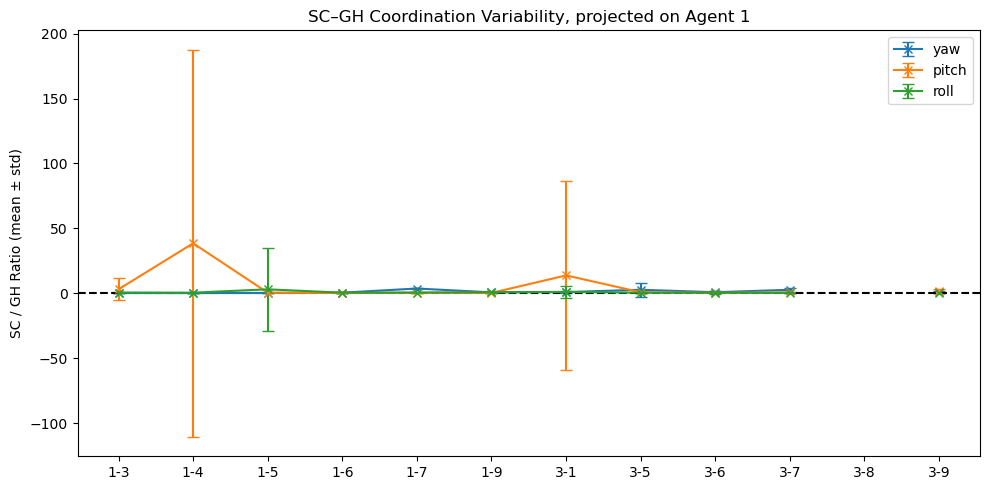

   projected_movement   axis       mean         std
0                 1-3    yaw   0.193308    0.010709
1                 1-3  pitch   3.092319    8.325157
2                 1-3   roll   0.571339    0.164791
3                 1-4    yaw   0.174482    0.010448
4                 1-4  pitch  38.498472  149.129874
5                 1-4   roll   0.467112    0.136388
6                 1-5    yaw   0.239670    0.062746
7                 1-5  pitch   0.463019    0.254041
8                 1-5   roll   3.055397   31.988992
9                 1-6    yaw   0.471663    0.124969
10                1-6  pitch   0.236506    0.063305
11                1-6   roll   0.459192    0.184266
12                1-7    yaw   3.673751    0.732105
13                1-7  pitch   0.364302    0.108152
14                1-7   roll   0.589106    0.056803
15                1-9    yaw   0.716653    0.184824
16                1-9  pitch   0.266674    0.230068
17                1-9   roll   0.835420    0.661280
18          

In [31]:
sc_gh_pairs = [
    ("yaw",   "sternoclavicular_yaw_joint",   "glenohumeral_yaw_joint"),
    ("pitch", "sternoclavicular_pitch_joint", "glenohumeral_pitch_joint"),
    ("roll",  "sternoclavicular_roll_joint",  "glenohumeral_roll_joint"),
]

rows = []

for movement in sorted(df["projected_movement"].unique()):

    subset = df[
        (df["projected_movement"] == movement) &
        (df["converged"])
    ]

    for axis, sc, gh in sc_gh_pairs:

        sc_vals = subset[f"{sc}_disp"].abs()
        gh_vals = subset[f"{gh}_disp"].abs()

        ratio = sc_vals / gh_vals.replace(0, np.nan)
        #ratio = np.log((sc_vals + 1e-8) / (gh_vals + 1e-8))

        rows.append({
            "projected_movement": movement,
            "axis": axis,
            "mean": ratio.mean(),
            "std": ratio.std() 
        })

stats_df = pd.DataFrame(rows)

plt.figure(figsize=(10,5))

for axis in stats_df["axis"].unique():

    sub = stats_df[stats_df["axis"] == axis]

    plt.errorbar(
        sub["projected_movement"],
        sub["mean"],
        yerr= sub["std"],
        label=axis,
        capsize=4,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean ± std)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

print(stats_df)

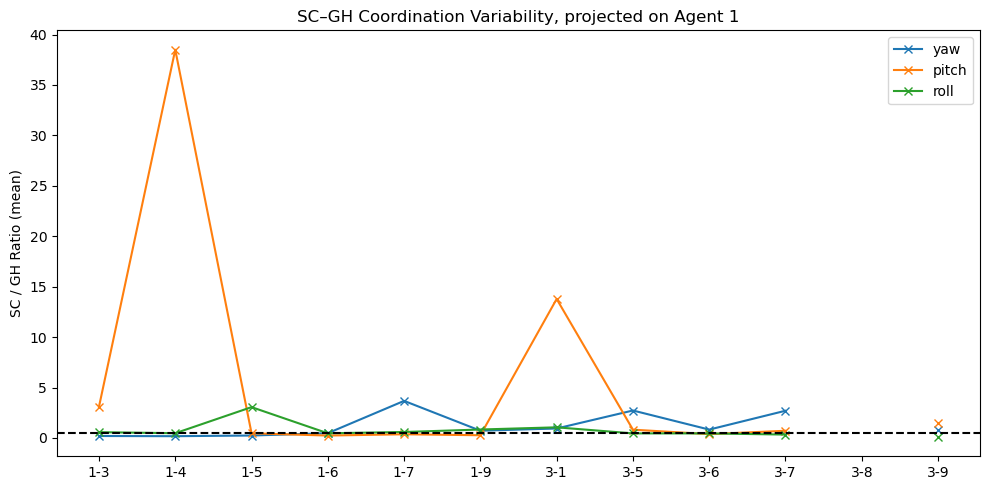

In [30]:
# same shit as before but without error bars:
plt.figure(figsize=(10,5))

# enforce consistent order
movement_order = sorted(stats_df["projected_movement"].unique())

for axis in stats_df["axis"].unique():

    sub = stats_df[stats_df["axis"] == axis]

    # force alignment with movement order
    sub = sub.set_index("projected_movement").reindex(movement_order).reset_index()

    plt.plot(
        sub["projected_movement"],
        sub["mean"],
        label=axis,
        marker="x"
    )

plt.axhline(0.5, linestyle="--", color="black")

plt.ylabel("SC / GH Ratio (mean)")
plt.title("SC–GH Coordination Variability, projected on Agent 1")

plt.legend()
plt.tight_layout()
plt.show()
